In [1]:
import os
import sys

# Get the path of the current file or notebook
current_path = os.path.abspath(__file__ if "__file__" in locals() else os.getcwd())

# Get the parent directory
parent_dir = os.path.dirname(current_path)
print(f"Parent directory: {parent_dir}")
# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import time

import matplotlib.pyplot as plt
import torch
from torch import device
from torch import float64 as torch_float64
from torch import get_num_threads, tensor, zeros

from scanner_modeling._plot._mpl_plot_system import (
    plot_polygons_from_vertices_mpl, plot_scanner_from_vertices_2d_mpl)
from scanner_modeling._raytracer_2d._local_functions import (
    ppdf_2d_local, reduced_edges_2d_local, sfov_properties,
    subdivision_grid_rectangle)
from scanner_modeling.geometry_2d import (fov_tensor_dict,
                                          load_scanner_geometry_from_layout,
                                          load_scanner_layouts)

Parent directory: /home/fanghan/Work/spebt/packages/pymatcal


In [24]:
default_device = device("cpu")

scanner_layout_file_relative_path = (
    "../scanner_layouts/scanner_layouts_e1531c3444e51439add2f18f5714fc50.tensor"
)
# Get the dir and filename from the relative path
scanner_layout_dir = os.path.dirname(scanner_layout_file_relative_path)
scanner_layout_filename = os.path.basename(scanner_layout_file_relative_path)

layout_idx = 0

start_time = time.time()

scanner_layouts, layouts_md5 = load_scanner_layouts(
    scanner_layout_dir,
    scanner_layout_filename,
)

# mu_dict = {"plate": 3.5, "crystal": 0.475}  # mm^-1
mu_dict = tensor([3.5, 0.475], device=default_device)

fov_dict = fov_tensor_dict((512, 512), (128, 128), (0.0, 0.0), (8, 8))

# crystal_n_subs = (5, 5)
crystal_n_subs = (5, 5)
sfov_pxs_ids, sfov_pixels_batch, sfov_corners_batch = sfov_properties(fov_dict)
fov_n_pxs = int(fov_dict["n pixels"].prod())
n_sfov = int(fov_dict["n subdivisions"].prod())
sfov_n_pxs = fov_n_pxs / int(fov_dict["n subdivisions"].prod())


sfov_pxs_ids_1d = (
    sfov_pxs_ids[:, :, 0] * fov_dict["n pixels"][0] + sfov_pxs_ids[:, :, 1]
)

print(f"PyTorch is set to use {get_num_threads()} threads for intra-op parallelism.")

subdivision_grid = subdivision_grid_rectangle(crystal_n_subs)

(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(layout_idx, scanner_layouts)

crystal_idx = 160



PyTorch is set to use 8 threads for intra-op parallelism.


In [25]:
reduced_crystal_edges_sfovs = []
reduced_plate_edges_sfovs = []
for sfov_idx in range(n_sfov):
    reduced_plate_edges, reduced_crystal_edges = reduced_edges_2d_local(
        sfov_idx,
        crystal_idx,
        sfov_corners_batch,
        plate_objects_vertices,
        plate_objects_edges,
        crystal_objects_vertices,
        crystal_objects_edges,
        default_device,
    )
    reduced_crystal_edges_sfovs.append(reduced_crystal_edges)
    reduced_plate_edges_sfovs.append(reduced_plate_edges)

In [26]:
ppdf = zeros(fov_n_pxs,dtype=torch_float64)
for sfov_idx in range(n_sfov):    
    ppdf[sfov_pxs_ids_1d[sfov_idx]] = ppdf_2d_local(
        sfov_idx,
        crystal_idx,
        sfov_pixels_batch,
        crystal_objects_vertices,
        reduced_plate_edges_sfovs[sfov_idx],
        reduced_crystal_edges_sfovs[sfov_idx],
        subdivision_grid,
        mu_dict,
        default_device,
    )

Text(0.5, 0.5, 'Crystal 160, ppdf mean: 70720613027.15, max: 15411183199785480.00')

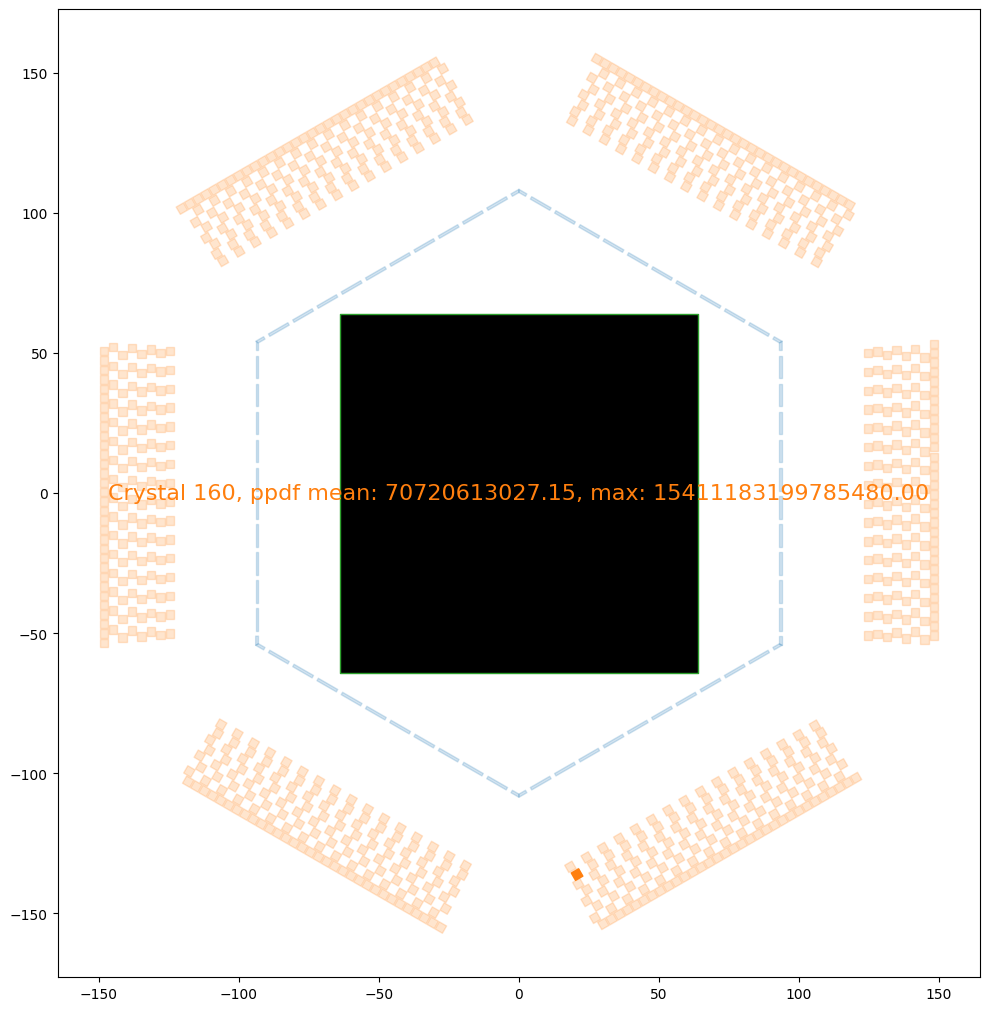

In [30]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
ax.imshow(
    ppdf.view(fov_dict["n pixels"].tolist()).T,
    origin="lower",
    interpolation="none",
    extent=(
        -fov_dict["size in mm"][0] * 0.5,
        fov_dict["size in mm"][0] * 0.5,
        -fov_dict["size in mm"][1] * 0.5,
        fov_dict["size in mm"][1] * 0.5,
    ),
    cmap="gray",
    vmin=0.0,
    vmax=ppdf.max(),
)
scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices,
    crystal_objects_vertices,
    ax,
    fov_dict,
    plate_alpha=0.2,
    crystal_alpha=0.2,
    fov_alpha=1,
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)
ax.annotate(
    f"Crystal {crystal_idx}, ppdf mean: {ppdf.mean():.2f}, max: {ppdf.max():.2f}",
    xy=(0.5, 0.5),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=16,
    color="C1",
)

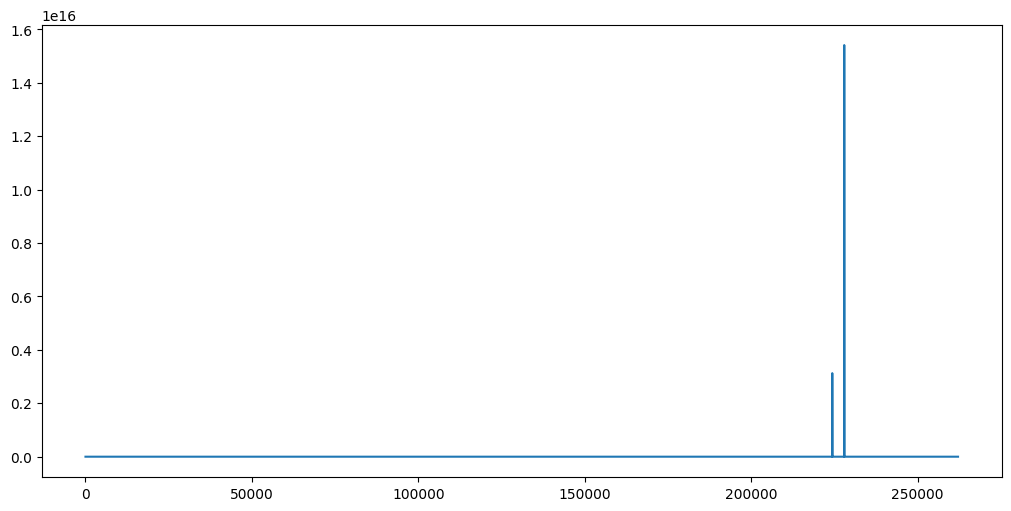

In [ ]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(
    range(fov_n_pxs),
    ppdf.view(fov_n_pxs).cpu().numpy(),
    color="C0",
    label=f"PPDF for crystal {crystal_idx}",
)
# remove the extrema from the ppdf


In [54]:
# Remove the outliers from the ppdf
indices =(ppdf.view(512,512)>1).argwhere()
ppdf_filtered = ppdf.view(512,512)
ppdf_filtered[indices[:, 0], indices[:, 1]] = 0.0
print(ppdf_filtered.shape)

torch.Size([512, 512])


Text(0.5, 0.5, 'Crystal 160\n mean: 2.48e-04\n max: 3.61e-03')

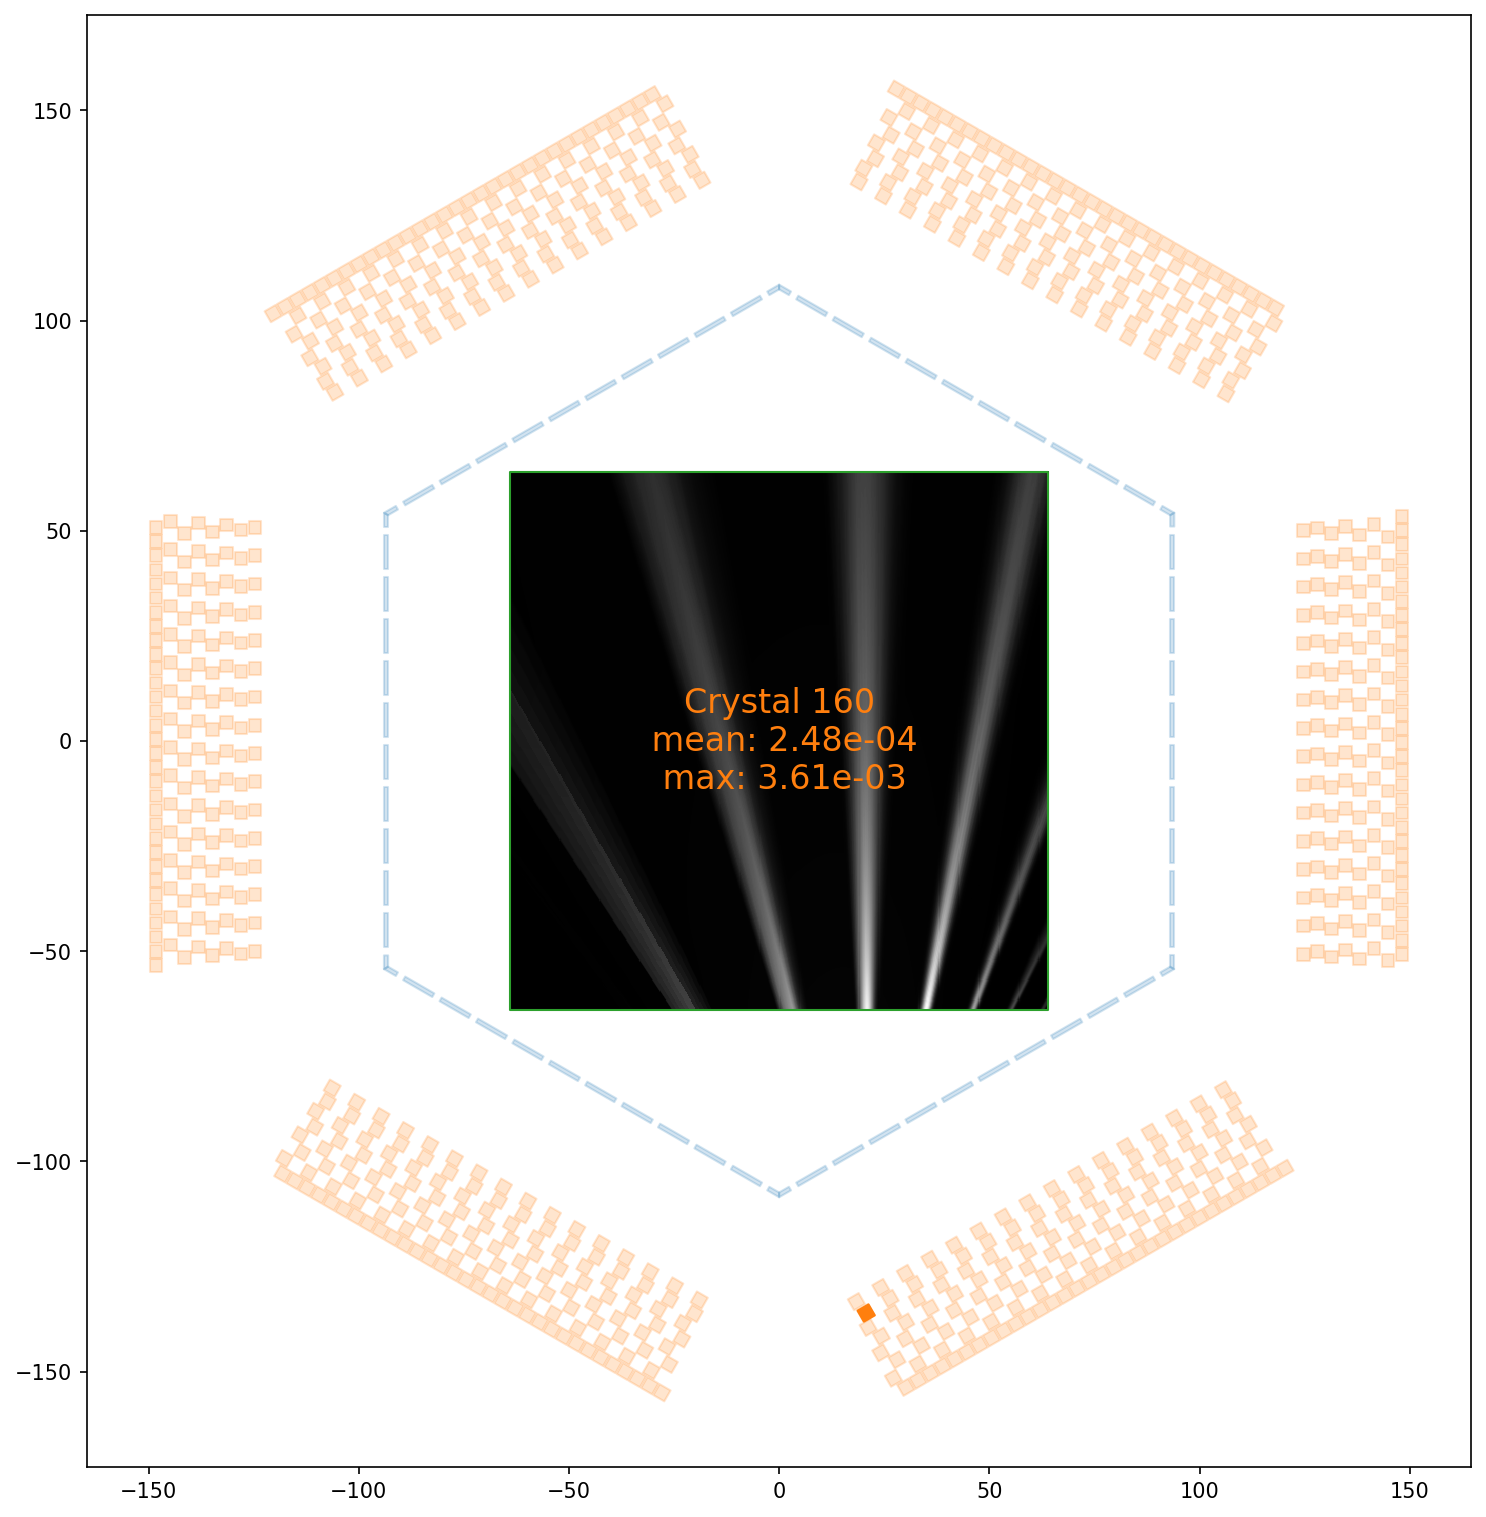

In [62]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained",dpi=150)
# ax.plot(
#     range(fov_n_pxs),
#     ppdf_filtered.flatten(),
#     color="C1",
#     label=f"Filtered PPDF for crystal {crystal_idx}",
# )
ax.imshow(
    ppdf_filtered.T,
    origin="lower",
    interpolation="none",
    extent=(
        -fov_dict["size in mm"][0] * 0.5,
        fov_dict["size in mm"][0] * 0.5,
        -fov_dict["size in mm"][1] * 0.5,
        fov_dict["size in mm"][1] * 0.5,
    ),
    cmap="gray",
    vmin=0.0,
    vmax=ppdf_filtered.max(),
)
scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices,
    crystal_objects_vertices,
    ax,
    fov_dict,
    plate_alpha=0.2,
    crystal_alpha=0.2,
    fov_alpha=1,
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)
ax.annotate(
    f"Crystal {crystal_idx}\n mean: {ppdf.mean():.2e}\n max: {ppdf.max():.2e}",
    xy=(0.5, 0.5),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=16,
    color="C1",
)

In [ ]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")